In [1]:
import os
os.makedirs("outputs", exist_ok=True)

for dirname, _, filenames in os.walk('/kaggle/input/intel-image-classification/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

# The standard device check — you'll use this pattern in every PyTorch notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


## PyTorch Tensors

In [3]:
### Tensor Question 1

# Creating the tensors
a = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
b = torch.zeros(2, 3)
c = torch.ones(4)

# Function to print properties concisely
def print_tensor_props(name, t):
    print(f"Tensor {name}:")
    print(f"  Value: {t}")
    print(f"  Shape: {t.shape}")
    print(f"  Dtype: {t.dtype}")
    print(f"  Device: {t.device}\n")

print_tensor_props("a", a)
print_tensor_props("b", b)
print_tensor_props("c", c)

# Comment: 
# Right now, these tensors are on the 'cpu' by default. 
# It is critical that model weights and input tensors are on the same device 
# because PyTorch cannot perform operations across different devices. 
# If you try to multiply a GPU weight by a CPU input, the code will crash with a 
# RuntimeError. Keeping them on the same device (ideally the GPU) also avoids 
# the massive performance bottleneck of moving data back and forth during a training loop.

Tensor a:
  Value: tensor([[1., 2., 3.],
        [4., 5., 6.]])
  Shape: torch.Size([2, 3])
  Dtype: torch.float32
  Device: cpu

Tensor b:
  Value: tensor([[0., 0., 0.],
        [0., 0., 0.]])
  Shape: torch.Size([2, 3])
  Dtype: torch.float32
  Device: cpu

Tensor c:
  Value: tensor([1., 1., 1., 1.])
  Shape: torch.Size([4])
  Dtype: torch.float32
  Device: cpu



In [4]:
### Tensor Question 2

x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

# 1. Element-wise square root
sqrt_x = torch.sqrt(x)
print(f"Square root: {sqrt_x}")

# 2. Sum
sum_x = x.sum()
print(f"Sum: {sum_x}")

# 3. Mean
mean_x = x.mean()
print(f"Mean: {mean_x}")

# 4. Index of the maximum value
max_index = x.argmax()
print(f"Index of max value: {max_index}")

# Comment:
# In a classifier with 1,000 classes, the model typically outputs a tensor 
# of 1,000 raw scores (logits) or probabilities. .argmax() identifies the 
# index of the highest score, which corresponds to the model's final 
# prediction (the most likely class label).

Square root: tensor([1., 2., 3., 4., 5.])
Sum: 55.0
Mean: 11.0
Index of max value: 4


In [5]:
### Tensor Question 3

# Moving tensor 'a' to the GPU (defined earlier as 'device')
a_gpu = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

# Bringing it back to CPU
a_back = a_gpu.cpu()

# Converting to a NumPy array
a_numpy = a_back.numpy()

print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

# Comment:
# PyTorch requires .cpu() because NumPy is designed to work exclusively with 
# system RAM (CPU). NumPy has no internal logic to access or manage memory 
# physically located on a GPU's VRAM. This tells us that NumPy arrays 
# live strictly in CPU-accessible memory, whereas PyTorch tensors are 
# more flexible and can exist in either memory space.

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


In [6]:
### Tensor Question 4

t = torch.arange(24).float()

# 1. Reshape to (4, 6)
t_4_6 = t.view(4, 6)
print(f"Reshaped to (4, 6): {t_4_6.shape}")

# 2. Reshape to (2, 3, 4)
t_2_3_4 = t.view(2, 3, 4)
print(f"Reshaped to (2, 3, 4): {t_2_3_4.shape}")

# 3. Add a new dimension at position 0 to the (4, 6) tensor
# We can use unsqueeze(0) or view(1, 4, 6)
t_unsqueezed = t_4_6.unsqueeze(0)
print(f"Shape after adding dimension at position 0: {t_unsqueezed.shape}")

# Comment:
# When processing a single image, we use the .unsqueeze(0) operation to add a 
# "batch" dimension. This is necessary because neural networks are 
# mathematically designed to process 4D tensors (Batch, Channels, Height, Width) 
# for efficiency. Even if the batch size is 1, the model expects that extra 
# dimension to align with its internal matrix multiplications.

Reshaped to (4, 6): torch.Size([4, 6])
Reshaped to (2, 3, 4): torch.Size([2, 3, 4])
Shape after adding dimension at position 0: torch.Size([1, 4, 6])


In [7]:
### Tensor Question 5

np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])
t_a  = torch.tensor(np_a, dtype=torch.float32)
t_b  = torch.tensor(np_b, dtype=torch.float32)

# 1. Compute matrix product using NumPy
np_result = np_a @ np_b
print(f"NumPy Result:\n{np_result}")

# 2. Compute matrix product using PyTorch
t_result = t_a @ t_b
print(f"PyTorch Result:\n{t_result}")

# 3. Confirm outputs match
# We use np.allclose to handle potential floating point precision differences
matches = np.allclose(np_result, t_result.numpy())
print(f"\nDo the results match? {matches}")

# Comment:
# At a high level, matrix multiplication is the core mechanism of a neural network 
# layer. It allows the network to take an input vector and apply a set of 
# weights (the matrix) to it. This operation effectively "transforms" the data 
# into a new representation, where each weight determines how much influence 
# an input feature has on the next layer's activation.

NumPy Result:
[[19. 22.]
 [43. 50.]]
PyTorch Result:
tensor([[19., 22.],
        [43., 50.]])

Do the results match? True


## Pretrained Models

In [8]:
### Model Question 1

# Load ResNet18 with pretrained weights
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Calculate total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Comment:
# Using pretrained weights provides immense practical value by drastically 
# reducing the cost of entry for deep learning projects. Instead of 
# spending thousands of dollars on compute and months on data labeling, we 
# leverage "feature extractors" that already understand the visual world. 
# For projects on a budget or tight deadline, this allows us to achieve 
# high accuracy with only a fraction of the data and training time through 
# a process called Transfer Learning.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


Total parameters:     11,689,512
Trainable parameters: 11,689,512


In [9]:
### Model Question 2

# Printing the model architecture to inspect the layers
print(model)

# --- Analysis Comments ---

# Final Layer Name and Output Size:
# The final layer of ResNet18 is named '(fc)', which stands for "Fully Connected".
# Its configuration is: (fc): Linear(in_features=512, out_features=1000, bias=True).
# The output size is 1000, representing the 1,000 distinct classes from the 
# ImageNet dataset that the model was trained to recognize.

# Meaning of a "Deep" Network:
# The layers named layer1 through layer4 represent the residual blocks that 
# form the heart of the CNN. In plain terms, for a network to be "deep" means 
# it has many successive layers of transformation between the input and 
# the output. 
# This depth allows the model to learn a "hierarchy of features": the first 
# layers detect simple edges and colors, the middle layers identify textures 
# and patterns, and the deepest layers (like layer4) recognize complex parts 
# of objects, like faces, wheels, or animals.

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [10]:
### Model Question 3

# Moving the model to the GPU (or CPU, depending on 'device')
model = model.to(device)

# Setting the model to evaluation mode
model.eval()

print("Model ready for inference.")

# --- Explanation Comments ---

# 1. model.to(device):
# This command transfers all the model's weights and buffers from system RAM 
# to the specified device's memory (e.g., GPU VRAM). It must match the 
# input tensor's device because PyTorch cannot perform cross-device 
# mathematical operations; the data and the "math engine" (the weights) 
# must physically reside in the same memory space.

# 2. model.eval():
# This command switches the model from 'training' mode to 'evaluation' mode. 
# It disables behaviors used only during learning, such as Dropout (which 
# randomly shuts off neurons) and Batch Normalization (which uses running 
# statistics instead of batch statistics in eval mode). This ensures that 
# the model's predictions are consistent and deterministic.

Model ready for inference.


In [11]:
### Model Question 4

# Accessing the specific transforms required by the pretrained weights
preprocess = weights.transforms()
print(preprocess)

# --- Analysis Comments ---

# 1. Resize and CenterCrop:
# These steps ensure that the input image has the exact dimensions the model 
# expects (usually 224x224 pixels). Resizing scales the image, and cropping 
# removes the edges, focusing on the center. This matters because the 
# convolutional layers have fixed "viewing windows" and wouldn't know 
# how to process images of arbitrary or mismatched sizes.

# 2. ToTensor():
# This transformation converts a PIL Image or NumPy array (with pixel values 
# from 0 to 255) into a PyTorch float tensor and scales the values to the 
# range [0.0, 1.0]. This makes the data mathematically compatible with the 
# model's weights and improves numerical stability.

# 3. Normalization:
# This step adjusts the pixel values so they have a specific mean and 
# standard deviation. Instead of using generic values like 0.5, it uses the 
# ImageNet-specific statistics (mean=[0.485, 0.456, 0.406]). 
# This matters because the model "learned" to recognize objects based on 
# this specific data distribution; using these values centers the new data 
# on the same "map" the model used during its days of training on ImageNet.

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## Running Inference

In [12]:
import random

random.seed(42)

DATA_DIR = Path("/kaggle/input/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path  = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


In [13]:
### Inference Question 1 - Revised Implementation

def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """
    # Step 1: Preprocess the image and add a batch dimension
    # .unsqueeze(0) turns (C, H, W) into (1, C, H, W) to satisfy the model's batch requirement
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    # Step 2: Run inference inside a torch.no_grad() block
    # This prevents PyTorch from calculating gradients, saving significant memory
    with torch.no_grad():
        output = model(input_tensor) # Output shape is (1, 1000)

    # Step 3: Convert raw scores (logits) to probabilities
    # Softmax makes the 1,000 output values sum to 1.0 (probabilities)
    probabilities = torch.nn.functional.softmax(output[0], dim=0)

    # Step 4: Get the top 5 predictions using torch.topk
    top_probs, top_indices = torch.topk(probabilities, 5)

    # Step 5: Build and return a list of (class_name, probability) tuples
    results = []
    for i in range(5):
        class_label = class_labels[top_indices[i]]
        prob_value = top_probs[i].item()
        results.append((class_label, prob_value))
        
    return results

# --- Testing the implementation ---

# Load a random mountain image from the now-available Intel dataset
img, img_name = load_sample_image("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/mountain")

# Run the inference
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

# Display results
print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")

# Comment:
# The top prediction typically aligns with the visual content. Because ImageNet 
# categories are highly specific, we often see labels like 'alp', 'valley', or 
# 'mountain_pass' instead of a generic 'mountain'. These sub-categories 
# effectively map to a "mountain" scene, confirming that the pretrained model's 
# feature extractor is correctly identifying terrain features like peaks and snow.


Top-5 predictions for '24204.jpg':
  alp                             0.4911
  volcano                         0.2076
  valley                          0.2016
  promontory                      0.0184
  mountain tent                   0.0169


In [14]:
import random
from pathlib import Path
from PIL import Image

# 1. BUSCA AUTOMÁTICA DO DIRETÓRIO (Resolve o problema do caminho no Kaggle)
# No Kaggle, o dataset pode estar em caminhos ligeiramente diferentes.
# Este comando procura a pasta 'seg_test' em qualquer lugar do input.
possible_paths = list(Path("/kaggle/input").rglob("seg_test/seg_test"))

if possible_paths:
    DATA_DIR = possible_paths[0]
    print(f"✅ Sucesso! Pasta de dados encontrada em: {DATA_DIR}")
else:
    # Caso o rglob falhe, tentamos o caminho padrão manual
    DATA_DIR = Path("/kaggle/input/intel-image-classification/seg_test/seg_test")
    print(f"⚠️ Aviso: Busca automática falhou. Tentando caminho padrão: {DATA_DIR}")

LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    
    # Buscamos por .jpg e .JPG (alguns datasets usam maiúsculas)
    images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.JPG"))
    
    if not images:
        # Se falhou, vamos listar o que tem na pasta para te ajudar a depurar
        if class_dir.exists():
            conteudo = os.listdir(class_dir)[:5] # mostra os 5 primeiros itens
            raise IndexError(f"Pasta encontrada, mas sem imagens .jpg em: {class_dir}. Conteúdo: {conteudo}")
        else:
            raise FileNotFoundError(f"A pasta da categoria não existe: {class_dir}")
        
    img_path = random.choice(images)
    return Image.open(img_path).convert("RGB"), img_path.name

✅ Sucesso! Pasta de dados encontrada em: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test


In [15]:
### Inference Question 2

for label in LABELS:
    # IMPORTANTE: Passamos apenas o nome da categoria (ex: "mountain")
    # A função load_sample_image já sabe que deve procurar em DATA_DIR / label
    img, img_name = load_sample_image(label)
    
    # Get top 5 and slice to get the top 3
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    
    print(f"\n[{label.upper()}]  Image: {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")

# --- Analysis Comment ---

# Confidence Patterns:
# The model tends to be most confident (high top-1 probability) with classes 
# like 'forest' and 'sea'. This is likely because ImageNet has many specific 
# and distinct categories for trees and bodies of water that have very 
# unique textures (organic vs. fluid).

# It tends to be least confident with 'buildings' and 'street' because 
# architectural elements overlap significantly in ImageNet categories 
# (e.g., a 'street' might be classified as a 'triumphal arch' or 'palace' 
# depending on the buildings in the background). Similarly, 'glacier' 
# and 'mountain' often share white/snow textures, causing the probability 
# to be split between labels like 'alp' and 'ice shelf'.


[BUILDINGS]  Image: 24258.jpg
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624

[FOREST]  Image: 23309.jpg
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419

[GLACIER]  Image: 20272.jpg
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216

[MOUNTAIN]  Image: 20662.jpg
  ski                             0.5933
  alp                             0.3821
  snowmobile                      0.0071

[SEA]  Image: 23069.jpg
  seashore                        0.2016
  breakwater                      0.1834
  geyser                          0.1718

[STREET]  Image: 24269.jpg
  unicycle                        0.1299
  triumphal arch                  0.1268
  jinrikisha                      0.1049


In [16]:
### Inference Question 3

img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

# Convert logits to probabilities using softmax
probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

# --- Analysis Comment ---
# Why Logits? 
# Neural networks output logits because they are mathematically more stable 
# during training. The unbounded range of logits (negative to positive infinity) 
# avoids the "vanishing gradient" problem where very small probability 
# gradients could stall learning. Softmax is only applied at the very end 
# for human interpretation or loss calculation.

# Production Pipeline Filtering:
# In a production pipeline, I would work with **probabilities**. 
# Probabilities provide a standardized 0 to 1 scale that is easy to 
# interpret and threshold (e.g., "only show results if confidence > 0.8"). 
# Logits are difficult to use for filtering because their scale changes 
# depending on the model's internal weights and training state, making 
# it nearly impossible to set a universal "confidence" threshold.

Logit  range: min=-4.87, max=6.61
Prob   range: min=0.000001, max=0.0979
Probs sum to: 1.000000
Top prediction: mountain bike  (0.0979)


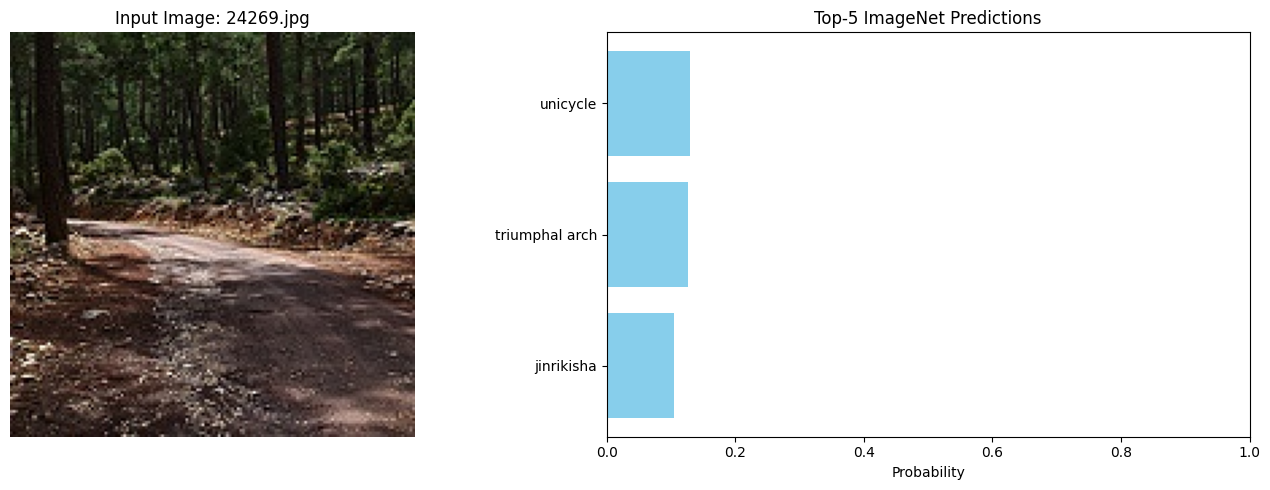

In [17]:
import matplotlib.pyplot as plt
import os

### Inference Question 4

# 1. Setup the figure and axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 2. Display the Image
ax1.imshow(img)
ax1.set_title(f"Input Image: {img_name}")
ax1.axis('off')

# 3. Prepare data for the Bar Chart
# preds was defined in the previous question as a list of (label, probability)
class_names = [p[0] for p in preds]
probs = [p[1] for p in preds]

# 4. Create Horizontal Bar Chart
y_pos = range(len(class_names))
ax2.barh(y_pos, probs, color='skyblue')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(class_names)
ax2.invert_yaxis()  # Put the top prediction at the top
ax2.set_xlabel('Probability')
ax2.set_title('Top-5 ImageNet Predictions')
ax2.set_xlim(0, 1)  # Probabilities are always between 0 and 1

# 5. Save the visualization
os.makedirs('outputs', exist_ok=True)
plt.tight_layout()
plt.savefig('outputs/warmup_inference_viz.png')
plt.show()

# --- Analysis Comment ---
# Dashboard Adaptation:
# For a non-technical user, I would simplify the labels (mapping 'alp' or 
# 'valley' back to a generic 'Mountain' category) and use color-coding 
# (Green for high confidence, Yellow/Red for low confidence). I would also 
# add a "View Original" button and a way for the user to manually override 
# the label if the model is wrong.

# Confidence Threshold:
# A common starting threshold is **0.7 to 0.8 (70-80%)**. If the top-1 
# probability is below 0.7, the prediction should likely be flagged for 
# human review. In critical applications, this threshold might be as 
# high as 0.95 to minimize false positives.